# Cálculo da Treliça

1) Vocês devem criar uma função que receba como entrada:
- Lista dos comprimento das barras da treliça;
- Lista das áreas das seções tranversais das treliças;
- Lista das Forças Externas (carregamentos).

2) VocÊs devem validar a função de deslocamento de vocês com o Ftool nos seguintes casos:
- 2.1 Variando um ou mais valores de comprimento de barra (caso 1);
- 2.2 Variando um ou mais valores de comprimento de barra (caso 2);
- 2.3 Variando um ou mais valores de comprimento de barra (caso 3);
- 2.4 Variando um ou mais valores de área da seção transversal de barra;
- 2.5 Variando uma ou mais forças de carregamento;

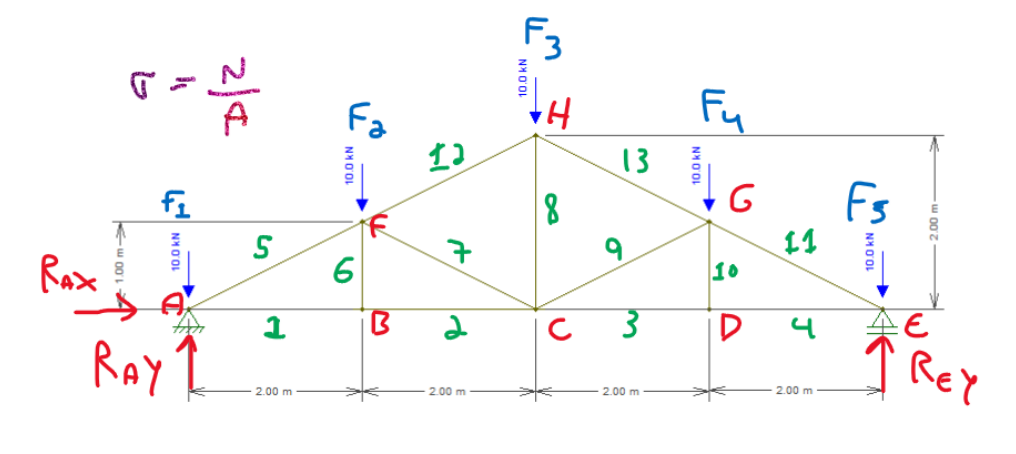

# Análise "Bruta" da Treliça de Howe

In [2]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prettytable import PrettyTable

### Comprimentos das Barras

In [3]:
def calcular_comprimentos_howe(l_bases, l_verticais):
    nos = np.array([
        [0.0, 0.0],
        [l_bases[0], 0.0],
        [l_bases[0] + l_bases[1], 0.0],
        [l_bases[0] + l_bases[1] + l_bases[2], 0.0],
        [sum(l_bases), 0.0],
        [l_bases[0], l_verticais[0]],
        [l_bases[0] + l_bases[1], l_verticais[1]],
        [l_bases[0] + l_bases[1] + l_bases[2], l_verticais[2]]
    ])

    barras = np.array([
        [0, 1], [1, 2], [2, 3], [3, 4],
        [0, 5],
        [1, 5],
        [5, 2],
        [2, 6],
        [2, 7],
        [3, 7],
        [7, 4],
        [5, 6],
        [6, 7]
    ])

    comprimentos = []
    angulos = []

    for i, j in barras:
        dx = nos[j][0] - nos[i][0]
        dy = nos[j][1] - nos[i][1]
        L = np.sqrt(dx**2 + dy**2)
        comprimentos.append(L)
        angulos.append((dx/L, dy/L))

    return nos, barras, comprimentos, angulos

### Áreas Transversais

In [4]:
def gerar_vetor_areas(num_barras, area):
    return [area for _ in range(num_barras)]

### Forças e Reações

A análise foi feita montando a Matriz de Equilíbrio dos Nós. As projeções em $X$ e $Y$ de cada barra e apoio são inseridas diretamente na matriz usando os cossenos e senos diretores obtidos na primeira função. A solução por álgebra linear entrega simultaneamente as forças nas barras e as reações de apoio.

As forças e reações de treliças isostáticas podem ser determinadas pela equação de equilibrio estático $ (\sum F_x = 0 e \sum F_y = 0) $. Essas equações lineares podem ser descritas na forma matricial:

$$
A \cdot x = P
$$

- A: matriz que contém os cossenos e senos diretores de cada barra.
- x: Vetor que contém as forças normais desconhecidas em cada barra seguidas pelas reações de apoio.
- P: Vetor que contém as cargas externas (No nosso caso, apenas o peso) aplicadas sobre os nós.

Para obter as cargas axiais, o sistema é resolvido pela multiplicação do vetor de cargas pela matriz inversa
$$
x = A^{-1} \cdot P
$$

In [5]:
def calcular_reacoes_e_forcas(nos, barras, angulos, forcas_externas, forcas_virtuais):
    num_nos = len(nos)
    num_barras = len(barras)
    num_reacoes = 3

    A = np.zeros((2 * num_nos, num_barras + num_reacoes))

    for k, (i, j) in enumerate(barras):
        cx, cy = angulos[k]
        A[2*i, k] = cx
        A[2*i+1, k] = cy
        A[2*j, k] = -cx
        A[2*j+1, k] = -cy

    A[0, num_barras] = 1.0
    A[1, num_barras + 1] = 1.0
    A[2*4+1, num_barras + 2] = 1.0

    P_real = np.zeros(2 * num_nos)
    for no, fx, fy in forcas_externas:
        P_real[2*no] = fx
        P_real[2*no+1] = fy

    P_virtual = np.zeros(2 * num_nos)
    for no, fx, fy in forcas_virtuais:
        P_virtual[2*no] = fx
        P_virtual[2*no+1] = fy

    solucao_real = np.linalg.solve(A, -P_real)
    solucao_virtual = np.linalg.solve(A, -P_virtual)

    f_real = solucao_real[:num_barras]
    reacoes_reais = solucao_real[num_barras:]
    f_virtual = solucao_virtual[:num_barras]

    return f_real, reacoes_reais, f_virtual

### Deslocamento pelo Trabalho Virtual

Para encontrar a deflexão de apenas um nó em uma diferação (Medir o deslocamento para baixo), utiliza-se o Princípio dos Trabalhos Virtuais (PTV):

$$ P.δ = ∑{\frac{F_{real} \cdot F_{virtual} \cdot L}{E \cdot A}} $$

Onde:

- P torna-se uma força ficticia (1) no nó alvo, gerando uma força virtual de tração ou compressão.
- $E \cdot A$ são as caracteristicas do material.
- $\delta$ é o deslocamento esperado.

In [6]:
def calcular_deslocamento_virtual(barras, comprimentos, areas, f_real, f_virtual, E_GPa=200.0):
    dados = []
    deslocamento_total = 0.0
    E_kNm2 = E_GPa * 1e6

    for k in range(len(barras)):
        L = comprimentos[k]
        A_sec = areas[k]
        F_kN = f_real[k]
        F_v = f_virtual[k]

        delta_m = (F_kN * F_v * L) / (E_kNm2 * A_sec)
        delta_mm = delta_m * 1000.0
        deslocamento_total += delta_mm

        dados.append({
            'Barra': f"{barras[k][0]}-{barras[k][1]}",
            'Comprimento (m)': round(L, 4),
            'Força Real (kN)': round(F_kN, 2),
            'Força Virtual (kN)': round(F_v, 2),
            'Deslocamento (mm)': round(delta_mm, 3)
        })

    df_resultados = pd.DataFrame(dados)

    df_resultados.index = np.arange(1, len(df_resultados) + 1)

    return df_resultados, deslocamento_total

### Plotagem da treliça e deslocamento

In [7]:
def desenhar_trelica_deslocada(nos, barras, angulos, comprimentos, areas, forcas_externas, E_GPa=200.0, fator_escala=50):
    num_nos = len(nos)
    K_global = np.zeros((2*num_nos, 2*num_nos))
    E_kNm2 = E_GPa * 1e6

    for k, (i, j) in enumerate(barras):
        cx, cy = angulos[k]
        L = comprimentos[k]
        A_sec = areas[k]
        k_el = (E_kNm2 * A_sec / L) * np.array([
            [cx*cx, cx*cy, -cx*cx, -cx*cy],
            [cx*cy, cy*cy, -cx*cy, -cy*cy],
            [-cx*cx, -cx*cy, cx*cx, cx*cy],
            [-cx*cy, -cy*cy, cx*cy, cy*cy]
        ])
        gls = [2*i, 2*i+1, 2*j, 2*j+1]
        for r in range(4):
            for c in range(4):
                K_global[gls[r], gls[c]] += k_el[r, c]

    gl_livres = list(range(2 * num_nos))
    gl_livres.remove(0)
    gl_livres.remove(1)
    gl_livres.remove(9)

    K_LL = K_global[np.ix_(gl_livres, gl_livres)]

    P_vetor = np.zeros(2 * num_nos)
    for no, fx, fy in forcas_externas:
        P_vetor[2*no] = fx
        P_vetor[2*no+1] = fy

    P_L = P_vetor[gl_livres]

    U_L = np.linalg.solve(K_LL, P_L)

    U_global = np.zeros(2 * num_nos)
    U_global[gl_livres] = U_L

    nos_deslocados = nos + U_global.reshape(-1, 2) * fator_escala

    plt.figure(figsize=(10, 5))

    for k, (i, j) in enumerate(barras):
        x = [nos[i][0], nos[j][0]]
        y = [nos[i][1], nos[j][1]]
        plt.plot(x, y, '--', linewidth=2, markersize=5, color='gray', zorder=2)

        x_d = [nos_deslocados[i][0], nos_deslocados[j][0]]
        y_d = [nos_deslocados[i][1], nos_deslocados[j][1]]
        plt.plot(x_d, y_d, 'r-', linewidth=1.5, zorder=3)

    plt.title(f"Treliça Howe - Deformação (Escala: {fator_escala}x)")
    plt.xlabel("Distância X (m)")
    plt.ylabel("Distância Y (m)")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

## Caso 1

In [8]:
# Entradas

l_bases = [3.0, 3.0, 3.0, 3.0]
l_verticais = [1.0, 2.0, 1.0]
forcas_externas = [
    (0, 0.0, -10.0),
    (5, 0.0, -10.0),
    (6, 0.0, -10.0),
    (7, 0.0, -10.0),
    (4, 0.0, -10.0),
]
forcas_virtuais = [
    (2, 0.0, -1.0)
]
area_transversal = 0.0005 # 500mm²

In [9]:
nos, barras, comprimentos, angulos = calcular_comprimentos_howe(l_bases, l_verticais)

f_real, reacoes, f_virtual = calcular_reacoes_e_forcas(nos, barras, angulos, forcas_externas, forcas_virtuais)

areas = gerar_vetor_areas(len(comprimentos), area_transversal)

df_resultados, desl_total_1 = calcular_deslocamento_virtual(barras, comprimentos, areas, f_real, f_virtual)

print(f"Deslocamento total da treliça: {desl_total_1:.8f} mm")

Deslocamento total da treliça: 16.20569415 mm


In [10]:
df_resultados

,Barra,Comprimento (m),Força Real (kN),Força Virtual (kN),Deslocamento (mm)
1,0-1,3.0000,45.00,1.50,2.025
2,1-2,3.0000,45.00,1.50,2.025
3,2-3,3.0000,45.00,1.50,2.025
4,3-4,3.0000,45.00,1.50,2.025
5,0-5,3.1623,-47.43,-1.58,2.372
6,1-5,1.0000,0.00,0.00,0.000
7,5-2,3.1623,-15.81,-0.00,0.000
8,2-6,2.0000,10.00,1.00,0.200
9,2-7,3.1623,-15.81,-0.00,0.000
10,3-7,1.0000,0.00,0.00,0.000


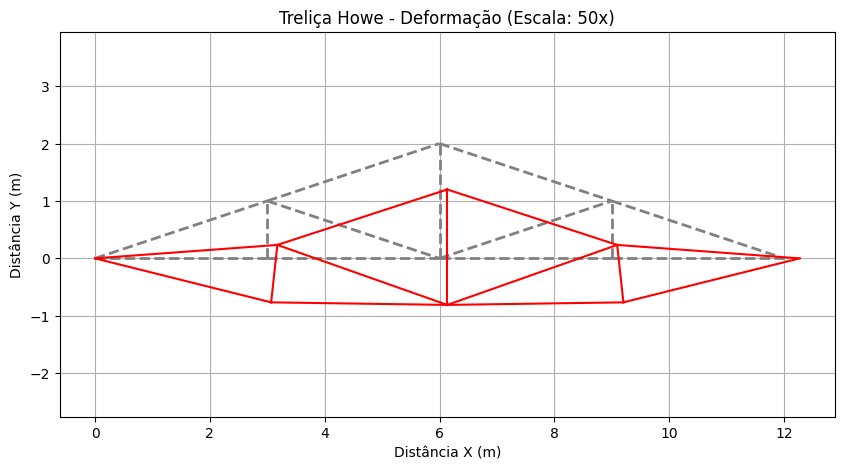

In [11]:
desenhar_trelica_deslocada(nos, barras, angulos, comprimentos, areas, forcas_externas)

## Caso 2

In [12]:
# Entradas - Caso 2

l_bases = [2.0, 2.0, 2.0, 2.0]
l_verticais = [2.0, 4.0, 2.0]
forcas_externas = [
    (0, 0.0, -10.0),
    (5, 0.0, -10.0),
    (6, 0.0, -10.0),
    (7, 0.0, -10.0),
    (4, 0.0, -10.0),
]
forcas_virtuais = [
    (2, 0.0, -1.0)
]
area_transversal = 0.0005 # 500mm²

In [13]:
nos, barras, comprimentos, angulos = calcular_comprimentos_howe(l_bases, l_verticais)

f_real, reacoes, f_virtual = calcular_reacoes_e_forcas(nos, barras, angulos, forcas_externas, forcas_virtuais)

areas = gerar_vetor_areas(len(comprimentos), area_transversal)

df_resultados, desl_total_2 = calcular_deslocamento_virtual(barras, comprimentos, areas, f_real, f_virtual)

print(f"Deslocamento total da treliça: {desl_total_2:.8f} mm")

Deslocamento total da treliça: 2.41421356 mm


In [14]:
df_resultados

,Barra,Comprimento (m),Força Real (kN),Força Virtual (kN),Deslocamento (mm)
1,0-1,2.0000,15.00,0.50,0.150
2,1-2,2.0000,15.00,0.50,0.150
3,2-3,2.0000,15.00,0.50,0.150
4,3-4,2.0000,15.00,0.50,0.150
5,0-5,2.8284,-21.21,-0.71,0.424
6,1-5,2.0000,0.00,0.00,0.000
7,5-2,2.8284,-7.07,0.00,-0.000
8,2-6,4.0000,10.00,1.00,0.400
9,2-7,2.8284,-7.07,0.00,-0.000
10,3-7,2.0000,0.00,0.00,0.000


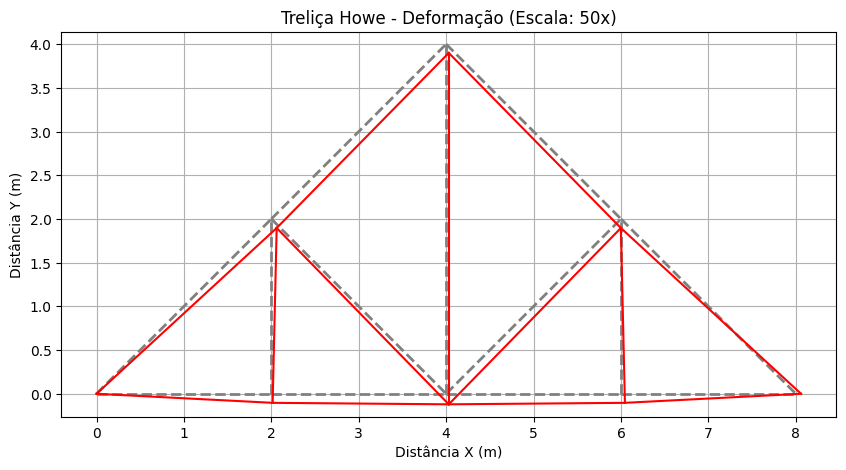

In [15]:
desenhar_trelica_deslocada(nos, barras, angulos, comprimentos, areas, forcas_externas)

## Caso 3

In [16]:
# Entradas - Caso 3

l_bases = [2.0, 2.0, 2.0, 4.0]
l_verticais = [1.0, 2.0, 2.0]
forcas_externas = [
    (0, 0.0, -10.0),
    (5, 0.0, -10.0),
    (6, 0.0, -10.0),
    (7, 0.0, -10.0),
    (4, 0.0, -10.0),
]
forcas_virtuais = [
    (2, 0.0, -1.0)
]
area_transversal = 0.0005 # 500mm²

In [17]:
nos, barras, comprimentos, angulos = calcular_comprimentos_howe(l_bases, l_verticais)

f_real, reacoes, f_virtual = calcular_reacoes_e_forcas(nos, barras, angulos, forcas_externas, forcas_virtuais)

areas = gerar_vetor_areas(len(comprimentos), area_transversal)

df_resultados, desl_total_3 = calcular_deslocamento_virtual(barras, comprimentos, areas, f_real, f_virtual)

print(f"Deslocamento total da treliça: {desl_total_3:.8f} mm")

Deslocamento total da treliça: 6.73811068 mm


In [18]:
df_resultados

,Barra,Comprimento (m),Força Real (kN),Força Virtual (kN),Deslocamento (mm)
1,0-1,2.0000,36.00,1.20,0.864
2,1-2,2.0000,36.00,1.20,0.864
3,2-3,2.0000,24.00,0.80,0.384
4,3-4,4.0000,24.00,0.80,0.768
5,0-5,2.2361,-40.25,-1.34,1.207
6,1-5,1.0000,0.00,0.00,0.000
7,5-2,2.2361,-11.18,0.00,-0.000
8,2-6,2.0000,3.00,0.60,0.036
9,2-7,2.8284,2.83,0.57,0.045
10,3-7,2.0000,0.00,0.00,0.000


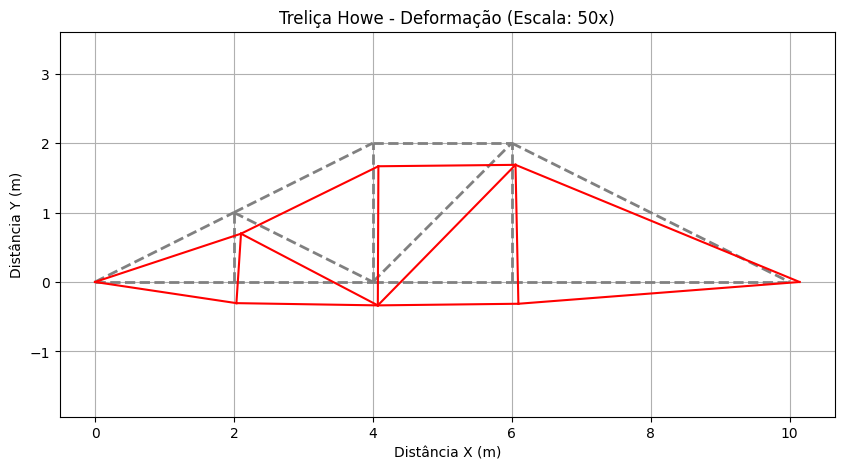

In [19]:
desenhar_trelica_deslocada(nos, barras, angulos, comprimentos, areas, forcas_externas)

## Caso 4

In [20]:
# Entradas - Caso 4

l_bases = [2.0, 2.0, 2.0, 2.0]
l_verticais = [1.0, 2.0, 1.0]
forcas_externas = [
    (0, 0.0, -10.0),
    (5, 0.0, -10.0),
    (6, 0.0, -10.0),
    (7, 0.0, -10.0),
    (4, 0.0, -10.0),
]
forcas_virtuais = [
    (2, 0.0, -1.0)
]
area_transversal = 0.0005 * 2 # 500mm²

In [21]:
nos, barras, comprimentos, angulos = calcular_comprimentos_howe(l_bases, l_verticais)

f_real, reacoes, f_virtual = calcular_reacoes_e_forcas(nos, barras, angulos, forcas_externas, forcas_virtuais)

areas = gerar_vetor_areas(len(comprimentos), area_transversal)

df_resultados, desl_total_4 = calcular_deslocamento_virtual(barras, comprimentos, areas, f_real, f_virtual)

print(f"Deslocamento total da treliça: {desl_total_4:.8f} mm")

Deslocamento total da treliça: 2.69754249 mm


In [22]:
df_resultados

,Barra,Comprimento (m),Força Real (kN),Força Virtual (kN),Deslocamento (mm)
1,0-1,2.0000,30.00,1.00,0.300
2,1-2,2.0000,30.00,1.00,0.300
3,2-3,2.0000,30.00,1.00,0.300
4,3-4,2.0000,30.00,1.00,0.300
5,0-5,2.2361,-33.54,-1.12,0.419
6,1-5,1.0000,0.00,0.00,0.000
7,5-2,2.2361,-11.18,-0.00,0.000
8,2-6,2.0000,10.00,1.00,0.100
9,2-7,2.2361,-11.18,0.00,-0.000
10,3-7,1.0000,0.00,0.00,0.000


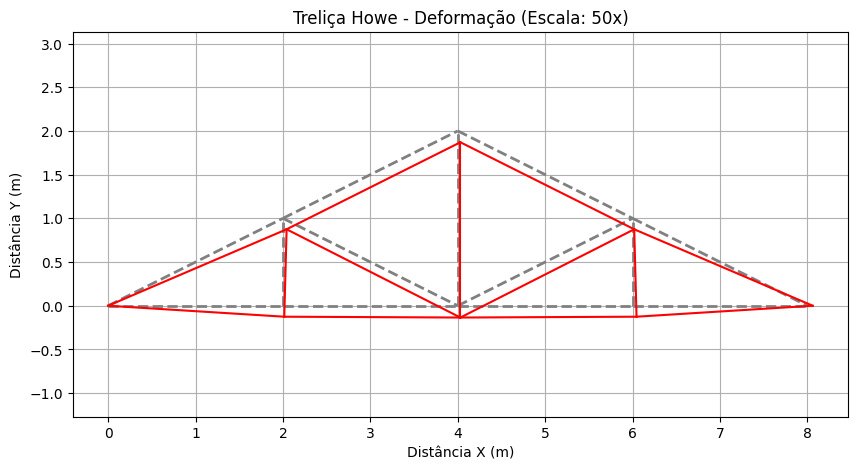

In [23]:
desenhar_trelica_deslocada(nos, barras, angulos, comprimentos, areas, forcas_externas)

## Caso 5

In [24]:
# Entradas - Caso 2

l_bases = [2.0, 2.0, 2.0, 2.0]
l_verticais = [1.0, 2.0, 1.0]
forcas_externas = [
    (0, 0.0, -10.0),
    (5, 0.0, -10.0),
    (6, 0.0, -20.0),
    (7, 0.0, -20.0),
    (4, 0.0, -10.0),
]
forcas_virtuais = [
    (2, 0.0, -1.0)
]
area_transversal = 0.0005 # 500mm²

In [25]:
nos, barras, comprimentos, angulos = calcular_comprimentos_howe(l_bases, l_verticais)

f_real, reacoes, f_virtual = calcular_reacoes_e_forcas(nos, barras, angulos, forcas_externas, forcas_virtuais)

areas = gerar_vetor_areas(len(comprimentos), area_transversal)

df_resultados, desl_total_5 = calcular_deslocamento_virtual(barras, comprimentos, areas, f_real, f_virtual)

print(f"Deslocamento total da treliça: {desl_total_5:.8f} mm")

Deslocamento total da treliça: 9.05164445 mm


In [26]:
df_resultados

,Barra,Comprimento (m),Força Real (kN),Força Virtual (kN),Deslocamento (mm)
1,0-1,2.0000,45.00,1.00,0.900
2,1-2,2.0000,45.00,1.00,0.900
3,2-3,2.0000,55.00,1.00,1.100
4,3-4,2.0000,55.00,1.00,1.100
5,0-5,2.2361,-50.31,-1.12,1.258
6,1-5,1.0000,0.00,0.00,0.000
7,5-2,2.2361,-11.18,-0.00,0.000
8,2-6,2.0000,15.00,1.00,0.300
9,2-7,2.2361,-22.36,0.00,-0.000
10,3-7,1.0000,0.00,0.00,0.000


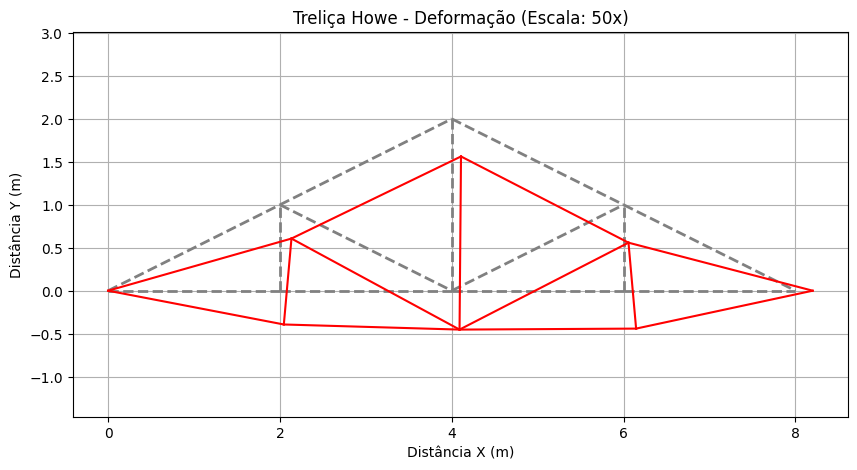

In [27]:
desenhar_trelica_deslocada(nos, barras, angulos, comprimentos, areas, forcas_externas)

## Comparação de Resultados com Ftool

In [28]:
table = PrettyTable()

table.field_names = ['FTool (mm)', 'Python (mm)']
table.add_row(['16,21', f'{desl_total_1:.3f}'])
table.add_row(['2,414', f'{desl_total_2:.3f}'])
table.add_row(['6,738', f'{desl_total_3:.3f}'])
table.add_row(['2,698', f'{desl_total_4:.3f}'])
table.add_row(['9,052', f'{desl_total_5:.3f}'])

print(table)

+------------+-------------+
| FTool (mm) | Python (mm) |
+------------+-------------+
|   16,21    |    16.206   |
|   2,414    |    2.414    |
|   6,738    |    6.738    |
|   2,698    |    2.698    |
|   9,052    |    9.052    |
+------------+-------------+


# Pensando o Fitness

## Cromossomo

A otimização para encontra a melhor treliça com determinados fatores é um problema bi-objetivo, ou seja, existem duas variáveis que podem ser otimizadas. No nosso caso, seria o formato (Utilizando o mesmo número de barras) e a seção de cada barra. Assim o nosso genes seriam os valores de comprimente (Altura e bases) e as áreas tranversais.

$$
l\_bases = [2.0, 2.0, 2.0, 2.0] \\
l\_verticais = [1.0, 2.0, 1.0] \\
area\_transversal = 0.0005
$$

$$
Cromossomo = [H_1, H_2, H_3, ..., B_1, B_2, B_3, ..., A_1, A_2, A_3, ...]
$$

## Função Fitness

O formato da treliça é definido pelas alturas dos nós e pelas larguras da base, enquanto a seção é uma lista de áreas transversais. Desse modo, é possível utilizar o volume, proporcional ao peso da treliça, para a função objetivo:

$$
V = \sum_{i=1}^{n} (L_i (H, B) \cdot A_i) \\
Fitness = \frac{1}{V}
$$

Os comprimentos são calculados internamente no código, então o AG só deverá alterar os valores das bases e das alturas.

## Penalidades

Otimizar o volume é o caminho certo, porém o AG provavelmente tenderá a minimizar o máximo que puder, ou seja, convergirá para barras finas e áreas pequenas. Por isso, aplicar uma penalidade é essencial para prevenir soluções distantes do ótimo.

- O nó alvo não pode ceder mais do que um limite fixo
- Nenhuma barra pode romper. Isto é calculado por meio da tensão (F/A) e também é comparado com um limite pré-definido.

No final, o custo será a soma do volume total e as penalidades.

$$
Custo = \sum_{i=1}^{n} (L_i (H, B) \cdot A_i) + P_1 \cdot (\delta - \delta_{max}) + P_2 \cdot \sum_{i=1}^{n}(T_i - T_{max})^2
$$

Onde:
 - P é uma constante fixa de penalidade
 - T é a tensão
 - $\delta$ é o deslocamento da treliça